# OK Cupid Matchmaking / Recommendations Project

## 1. Importing python modules and User profiles dataset
***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import src.date_a_scientist.support as support

# Import User profiles dataset
df = pd.read_csv('../data/profiles.csv')
print("Initial user count: ",df.shape[0])

print("First Entry:")
print(df.iloc[0].T)


Initial user count:  59946
First Entry:
age                                                           22
body_type                                         a little extra
diet                                           strictly anything
drinks                                                  socially
drugs                                                      never
education                          working on college/university
essay0         about me:<br />\n<br />\ni would love to think...
essay1         currently working as an international agent fo...
essay2         making people laugh.<br />\nranting about a go...
essay3         the way i look. i am a six foot half asian, ha...
essay4         books:<br />\nabsurdistan, the republic, of mi...
essay5         food.<br />\nwater.<br />\ncell phone.<br />\n...
essay6                               duality and humorous things
essay7         trying to find someone to hang out with. i am ...
essay8         i am new to california and looking 

## 2. Data Preprocessing and Preparation
***

### 2.0 – Unique Values by Column

In [2]:
# Let's look at the User data by column.

# FIRST let's assign Users a unique ID, using User index:
df.insert(0,'user_id',df.index)

print(support.unique_and_missing_values(df)) # Returns dataframe of unique values and missing values by column.
print("\nCurrent Total User Count:",df.shape[0])



Number of unique and missing values by column:

             unique_values  missing_values
column                                    
user_id              59946               0
age                     54               0
body_type               12            5296
diet                    18           24395
drinks                   6            2985
drugs                    3           14080
education               32            6628
ethnicity              217            5680
height                  60               3
income                  13               0
job                     21            8198
last_online          30123               0
location               199               0
offspring               15           35561
orientation              3               0
pets                    15           19921
religion                45           20226
sex                      2               0
sign                    48           11056
smokes                   5            5512
speak

### 2.1 – Handling Inactive Users
- DROP **4699** users from matchmaking who have not been active for greater than 7 months

In [3]:
# Let's look at User Activity:

support.print_last_online(df) # Prints users last_online by year and number of users online today.

# DROP Users who have not logged in since 2011 (7 months of inactivity)
df = df[df.last_online.apply(lambda x: "2011" not in x)]

print("\nCurrent Total Users Count: ",df.shape[0])


TODAY IS: 2012-07-01

Users last_online by year:
2012: 55247
2011: 4699

Today's user count: 2090

Current Total Users Count:  55247


### 2.1.1 – Last Online Priority Weighting
- ADD *`last_online_date`*, *`last_online_weeks`*, and *`last_online_priority`*
- DROP `last_online`
- The new priority weighting feature boosts users who have used the app more recently

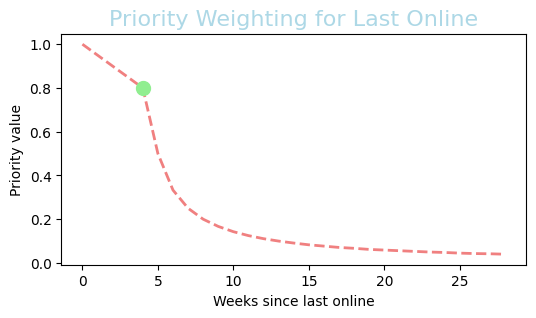

Example for User @ index 10
Weeks since last online: 4 

Priority value:  0.8 

Current Total Users Count:  55247 



In [4]:
# Let's prioritize users who have used the app recently:

def priority_function(x):
    return (20 - x)/20 if x < 5 else round(1/(x-3),3)

# Prompt for user index to evaluate
index_input = input('Enter index of user to evaluate: ')
try:
    index_input = int(index_input)
except ValueError as e:
    print("Invalid input. Please enter an integer. (entered: ",index_input,")")

# ADD features
support.last_online_priority(df,priority_function) # ADD features: `last_online_date`, `last_online_weeks`, and `last_online_priority`

# PLOT
support.plot_last_online_priority(df, priority_function, uindex = index_input) # PLOT last_online_priority

# DROP `last_online` feature - we will use the new features instead.
df = df.drop(columns=['last_online'])

print('Current Total Users Count: ',df.shape[0],'\n')


### 2.2 – Ready-to-match status
- ADD feature `ready_to_match` to Encode a user's readiness to match based on their status
- DROP **2032** Users who are NOT `ready_to_match`
- DROP `status` feature

In [5]:
# Let's look at User 'status':

print(df.status.value_counts())

# ADD feature: `ready_to_match`, True if user is 'single' or 'available'
df['ready_to_match'] = df.status.apply(lambda x: True if x in ['single','available'] else False)
print(f'\n{df.ready_to_match.value_counts()}\n')

# DROP Users who are NOT `ready_to_match`
df = df[df['ready_to_match'] == True]

# DROP `status` feature - we will use `ready_to_match` instead.
df = df.drop(columns=['status'])

print('Current Total Users Count:',df.shape[0])


status
single            51482
seeing someone     1773
available          1729
married             255
unknown               8
Name: count, dtype: int64

ready_to_match
True     53211
False     2036
Name: count, dtype: int64

Current Total Users Count: 53211


### 2.3 – User Geographic Locations
- This dataset **ONLY** supports finding matches for users in California state.

In [6]:
# Let's look at User Locations:
# Evaluate number of users in a per-state basis to better understand distribution and representation

support.user_location_support(df) # Prints user count, in and out of California State

print("\nCurrent Total Users Count: ",df.shape[0])



Total USA based users:      53204
California based users:     53124
Non-California USA users:   80
International based users:  7 

Percentage of users outside California: 0.16%

Current Total Users Count:  53211


### 2.3.1 – Dropping Non-California-Based Users
- Drops **87** users who live outside California State.

In [7]:
# Let's DROP users who are not in California State (See above)
df = df[df.location.str.contains('california')]

# Test for any remaining users outside of California State.
for test_location in df.location.unique():
    if 'california' not in test_location:
        print(ValueError(f'WARNING: User location: \'{test_location}\' is not in California State.'))

print(f'Cities with users in California: {df.location.nunique()}\n')
print(f'Top city: {df.location.value_counts().index[0].title()} with {df.location.value_counts().iloc[0]} users.  '
      f'({df.location.value_counts().iloc[0] / df.shape[0] * 100:.2f}% of total users)')
print(f'Top five cities: {df.location.value_counts()[:5].sum() / df.shape[0] * 100:.2f}','% of total users')
print(f'Top fifty cities: {df.location.value_counts()[:50].sum() / df.shape[0] * 100:.2f}','% of total users')

print("\nCurrent Total Users Count: ",df.shape[0])


Cities with users in California: 132

Top city: San Francisco, California with 27862 users.  (52.45% of total users)
Top five cities: 75.41 % of total users
Top fifty cities: 99.21 % of total users

Current Total Users Count:  53124


### 2.4 – Religious Affiliation and Importance
- DROP `religion` feature - we will use the OHE features instead.

In [8]:
# Let's look at Religion:

# 'religion' top ten user responses
print(f'INPUT: top 5 \n{df.religion.value_counts()[:5]}\n')

# ADD features: `religion_affiliation`, `religion_serious`, `religion_somewhat`,
# `religion_little`, `religion_laughing`, and `religion_none`
support.ohe_religion(df) # Manual OHE of 'religion' feature

print('OUTPUT: top 5')
print(df.religion_affiliation.value_counts()[:5])

# DROP `religion` feature - use the OHE features instead.
df = df.drop(columns=['religion'])

print("\nCurrent Total User Count:",df.shape[0])


INPUT: top 5 
religion
agnosticism                                 2469
other                                       2418
agnosticism but not too serious about it    2340
agnosticism and laughing about it           2196
catholicism but not too serious about it    2060
Name: count, dtype: int64

OUTPUT: top 5
religion_affiliation
none            17977
agnosticism      7835
other            6838
atheism          6132
christianity     5045
Name: count, dtype: int64

Current Total User Count: 53124


### 2.5 – Astrological Sign Importance
- DROP `sign` feature

In [9]:
# Let's look at Astrological Signs:

# replace special character in 'sign' feature
df.sign = df.sign.str.replace('&rsquo;','\'',regex=False)

support.do_signs_matter(df) # Less than 2% of Users place high importance on their sign.

# DROP `sign` feature
df = df.drop(columns=['sign'])

print("\nCurrent Total User Count:",df.shape[0])


Astrological Sign 'matters a lot':
  Aries: 1.13%
  Aquarius: 1.36%
  Cancer: 1.36%
  Capricorn: 1.20%
  Gemini: 1.45%
  Leo: 1.36%
  Libra: 1.07%
  Pisces: 1.49%
  Sagittarius: 1.20%
  Scorpio: 1.78%
  Taurus: 1.08%
  Virgo: 0.88%

% Users who did not provide a sign: 18.37%

Current Total User Count: 53124


### 2.6 – User Drinking and Drug Use
- New `df_dummies` DataFrame with OHE features for `drinks`, `drugs`, and `smokes`

In [10]:
# Let's look at User drinking and drug use:

# Fill missing values for 'drinking' and 'drugs'
df.drinks = df.drinks.fillna('unknown')
df.drugs = df.drugs.fillna('unknown')

# Replace spaces with underscores before get_dummies() creates new columns
df['drinks'] = df['drinks'].str.replace(' ','_')
df['smokes'] = df['smokes'].str.replace(' ','_')

# Good candidate for OHE using get_dummies()
print(f'Unique values by feature: \n{df[['drinks', 'drugs', 'smokes']].nunique()}')

# OHE
df = pd.get_dummies(df, columns = ['drinks', 'drugs', 'smokes'])

print("\nCurrent Total Users Count: ",df.shape[0])


Unique values by feature: 
drinks    7
drugs     4
smokes    5
dtype: int64

Current Total Users Count:  53124


### 2.7 – Language (*speaks*)
- ALL users that provided an input listed English as a language that they speak.
- DROP `speaks` feature

In [11]:
# Let's look at User Language(speaks):

print('Language unknown/empty: ',df.speaks.isna().sum() + df.speaks.str.contains('unknown').sum())
df.speaks = df.speaks.fillna('unknown')

print('English speaking users: ',df[df.speaks.str.contains('english')].shape[0])
print('Spanish speaking users: ',df[df.speaks.str.contains('spanish')].shape[0])
print('Multilingual users:     ',df.speaks.str.contains(',').sum())
print()

# ALL users that provided inputs have listed English as a language they speak.
print('English + unknown:      ',df[df.speaks.str.contains('english')].shape[0] + df.speaks.str.contains('unknown').sum())

# DROP `speaks` feature
df = df.drop(columns=['speaks'])

print('Current Total Users Count:',df.shape[0])


Language unknown/empty:  44
English speaking users:  53080
Spanish speaking users:  14620
Multilingual users:      27406

English + unknown:       53124
Current Total Users Count: 53124


### 2.8 – Income
- DROP `income` feature

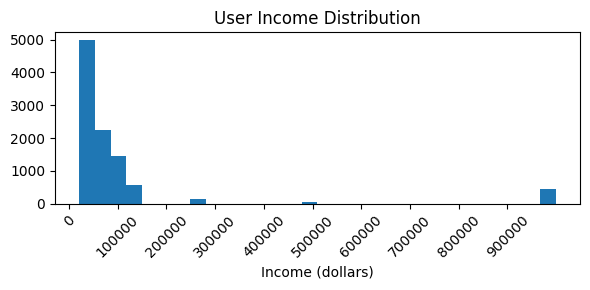

81.47% of users left income blank

User income distribution: 
count       9844.0
mean      105580.0
std       201242.1
min        20000.0
50%        50000.0
max      1000000.0
Name: income, dtype: float64 



In [12]:
# Let's look at User Income (lots of missing values)

df.income = df.income.apply(lambda x: x if x != -1 else np.nan)

plt.figure(figsize=(6,3))
plt.title('User Income Distribution')
plt.xlabel('Income (dollars)')
plt.xticks(np.arange(0,1000000,100000),rotation=45)
plt.hist(df.income,bins=30)
plt.tight_layout()
plt.show()

print(f'{(df.income.isna().sum() / df.shape[0] * 100).round(2)}% of users left income blank\n')
print('User income distribution: ')
print(df.income.describe([0.5]).round(1),'\n')

# DROP `income` feature
df = df.drop(columns=['income'])

### 2.9 – User Age

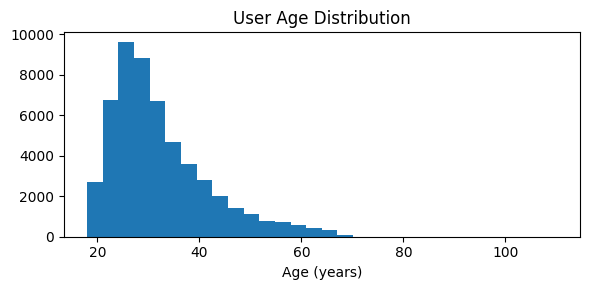

Currently, 2620 users over 52 years old.

Current Total Users Count:  53124 



In [13]:
# Let's look at User Age

# AGE distribution
plt.figure(figsize=(6,3))
plt.title('User Age Distribution')
plt.xlabel('Age (years)')
plt.hist(df.age,bins=30)
plt.tight_layout()
plt.show()

print('Currently,',df[df.age > 52].shape[0],'users over 52 years old.')

print('\nCurrent Total Users Count: ',df.shape[0],'\n')


### 2.9.1 – User Offspring
- DROP `offspring` feature

In [14]:
# Let's look at User 'offspring':

# Missing many values
df.offspring = df.offspring.fillna('unknown')
df.offspring = df.offspring.str.replace('&rsquo;','\'',regex=False)
print(f'Users missing a response for "offspring": {df.offspring.value_counts()['unknown']/df.shape[0] * 100:.2f}%\n')
print('Top 3 \'offspring\' values:')
print(df.offspring.value_counts()[:3])

# Drop 'offspring' feature
df = df.drop(columns=['offspring'])

print('\nCurrent Total Users Count: ',df.shape[0],'\n')


Users missing a response for "offspring": 56.91%

Top 3 'offspring' values:
offspring
unknown                                   30231
doesn't have kids                          7419
doesn't have kids, but might want them     3799
Name: count, dtype: int64

Current Total Users Count:  53124 



### 2.9.2 – Filling ALL Remaining Missing Values

In [15]:
# Let's fill in numeric columns first.
num_cols = df.select_dtypes(include='number').isna().sum()

# Only numeric column missing values is height:
df.height = df.height.fillna(df.height.mean())

# Let's fill in the rest of the columns (excluding 'essays')
str_cols = list()
for col in list(df.columns):
    if 'essay' in col:
        continue
    else:
        str_cols.append(col)

df[str_cols] = df[str_cols].fillna('unknown')

# Let's fill in the essay columns:
df = df.fillna(' ')


### 2.9.3 – Review Expected Values and Structure

In [16]:
check_index = 10
try:
    check_index = int(input('Check User Index: '))
    print(f'Showing user at index {check_index}:')
except ValueError as e:
    print('Error: ',e,f'\nShowing user at index {check_index}:')

print(df.iloc[check_index].T) # Spot-check users for expected values and OHE.


Showing user at index 10:
user_id                                                                 10
age                                                                     35
body_type                                                          average
diet                                                       mostly anything
education                                                          unknown
essay0                   update: i'm seeing someone, so off the market ...
essay1                   i have three jobs. i've been doing sound and l...
essay2                   hugging, kissing, laughing, motivating people,...
essay3                                                 my huge goofy smile
essay4                   i'm constantly reading, i read at what my frie...
essay5                   family<br />\nfriends<br />\nfood<br />\nwomen...
essay6                   snowboarding, food, women, goofy nerd stuff, a...
essay7                   having dinner and drinks with friends and/or w...

# 3. Essay Vectorization / Model Preparation
***

### 3.0 – Essay Preparation for TF-IDF Vectorization

In [17]:
# Let's prepare the Users Essays for TF-IDF Vectorization
import re

# User essays
user_raw_essays_combined = df[['essay0','essay1','essay2','essay3','essay4','essay5','essay6','essay7','essay8','essay9']].fillna(' ')

# Combine into a single string for each user
df['combined_essays'] = user_raw_essays_combined.apply(lambda x: ' '.join(x), axis=1)
print('Input:')
print(df.combined_essays.head())


# regex function to remove punctuation and special characters
def remove_spec_char(text):
    return re.sub(r'[^\w\s\']',' ',text)

df.combined_essays = df.combined_essays.replace('&rsquo;','',regex=False)
df.combined_essays = df.combined_essays.apply(remove_spec_char)


# Remove simple stop words and words with < 3 characters.
stop_words = ['and','the','this']
df.combined_essays = df.combined_essays.apply(lambda x: ' '.join(word for word in x.split() if (word.lower() not in stop_words) & (len(word) > 2)))


print('\nOutput:')
print(df.combined_essays.head())


del user_raw_essays_combined


Input:
0    about me:<br />\n<br />\ni would love to think...
1    i am a chef: this is what that means.<br />\n1...
2    i'm not ashamed of much, but writing public te...
3    i work in a library and go to school. . . read...
4    hey how's it going? currently vague on the pro...
Name: combined_essays, dtype: object

Output:
0    about would love think that was some some kind...
1    chef what that means workaholic love cook rega...
2    i'm not ashamed much but writing public text o...
3    work library school reading things written old...
4    hey how's going currently vague profile know m...
Name: combined_essays, dtype: object


### 3.1 – Most Common Words used by our users:

In [18]:
# Let's look at user essays: Word count, unique words, top 15 words
master_document_of_essays = ' '.join(essay for essay in df.combined_essays)
master_essay_series = pd.Series(master_document_of_essays.split()).replace('\'','',regex=True)
print('Total word count: ',len(master_essay_series))
print('Unique word count:',master_essay_series.nunique(),'\n')

# Most common words
print('Top 15 words: ')
print(list(master_essay_series.value_counts()[:15].index))

# Storing for use later. TF-IDF prioritizes lower frequency terms, thus we may be able to trim these.
top_50_words = list(master_essay_series.value_counts()[:50].index)


Total word count:  14094453
Unique word count: 149039 

Top 15 words: 
['im', 'you', 'with', 'for', 'that', 'have', 'like', 'but', 'love', 'not', 'out', 'are', 'interests', 'good', 'href']


### 3.2 – User Orientation and Splitting Dataset for Matchmaking

In [19]:
# Let's look at User Orientation:

# orientation = 'gay'
df_gay_men = df[(df.sex == 'm') & (df.orientation == 'gay')]
df_gay_women = df[(df.sex == 'f') & (df.orientation == 'gay')]

# orientation = 'bisexual'
df_bi_men = df[(df.sex == 'm') & (df.orientation == 'bisexual')]
df_bi_women = df[(df.sex == 'f') & (df.orientation == 'bisexual')]

# orientation = 'straight'
df_straight_men = df[(df.sex == 'm') & (df.orientation == 'straight')]
df_straight_women = df[(df.sex == 'f') & (df.orientation == 'straight')]

"""
Users with 'gay' orientation will be matched internally within their dataframe.

Users with 'straight' orientation will be matched between male and female dataframe.

Users with 'bisexual' orientation will have the opportunity to match in either grouping.

"""

# CONCAT applicable DataFrames to accomodate for User orientation:
df_gay_men_matchmaking = pd.concat([df_bi_men,df_gay_men],ignore_index=True)
df_gay_women_matchmaking = pd.concat([df_bi_women,df_gay_women],ignore_index=True)

df_straight_women_matchmaking = pd.concat([df_bi_women,df_straight_women],ignore_index=True)
df_straight_men_matchmaking = pd.concat([df_bi_men,df_straight_men],ignore_index=True)



### 3.3 – TF-IDF Vectorization
- Information on [TF-IDF](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) (Term Frequency – Inverse Document Frequency)

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words = top_50_words)

# Gay - Male - TF-IDF
gay_m_tfidf_matrix = vectorizer.fit_transform(df_gay_men_matchmaking.combined_essays)
gay_m_tfidf_array = gay_m_tfidf_matrix.toarray()

# Gay - Female - TF-IDF
gay_f_tfidf_matrix = vectorizer.fit_transform(df_gay_women_matchmaking.combined_essays)
gay_f_tfidf_array = gay_f_tfidf_matrix.toarray()


### 3.4 – Cosine Similarity

In [21]:
from sklearn.metrics.pairwise import cosine_similarity

# Cosine Similarity - explicit measure of angular similarity between two vectors
gay_m_similarity_matrix = cosine_similarity(gay_m_tfidf_array)

user_index = 0
print(f'Top five matches \nUser {user_index}: {np.argsort(gay_m_similarity_matrix[user_index])[-6:-1][::-1]}')

Top five matches 
User 0: [ 609  227 2719 2711  362]


### 3.5 – Alternating Least Squares (ALS)

In [22]:
from implicit import als
from scipy.sparse import csr_matrix

gay_m_sparse = csr_matrix(gay_m_tfidf_matrix).T.tocsr()

# Alternating Least Squares – implicit recommendations based on latent factors
gay_m_als = als.AlternatingLeastSquares(factors=128,regularization=0.1,iterations=15,use_gpu=False)
gay_m_als.fit(gay_m_sparse,show_progress=False)

# Retrieve top 5 matches for user 0
user_index = 0
ids,scores = gay_m_als.recommend(user_index,gay_m_sparse[user_index],N=5)
print(f'Top five matches \nUser {user_index}: {ids}')

Top five matches 
User 0: [  96 3120 2154  332 2180]


# Matchmaking Model
***
* IF LOADING NPY FILES → **4.4**
* ELSE → **4.0**
***

### 4.0 – Matchmaking – Opposite Sex

In [23]:
# Let's vectorize the matchmaking essays
from sklearn.feature_extraction.text import TfidfVectorizer

# Fit the vectorizer on ALL comments to create shared vocabulary
matchmaking_essays = pd.concat([df_straight_men_matchmaking.combined_essays, df_straight_women_matchmaking.combined_essays],ignore_index=True)
vectorizer = TfidfVectorizer(stop_words=stop_words)
vectorizer.fit(matchmaking_essays)

# Transform each group separately
men_tfidf = vectorizer.transform(df_straight_men_matchmaking.combined_essays)   # Shape: (num_men, num_features)
women_tfidf = vectorizer.transform(df_straight_women_matchmaking.combined_essays)

# Multiply Men (Users) by Women (Items) to get similarity scores
# Resulting shape: (num_men, num_women)
men_women_interaction = men_tfidf.dot(women_tfidf.T)

print('interaction shape:\n(men, women): ',men_women_interaction.shape)
# Convert to CSR format (required by implicit)
men_women_csr = men_women_interaction.tocsr()

# Transform to Item-User (Women x Men) for fitting
item_user_matrix = men_women_csr.T.tocsr()

del men_tfidf,women_tfidf

interaction shape:
(men, women):  (28380, 19897)


### 4.1 – ALS Model

In [24]:
from implicit import als

# Initialize and fit the model
model = als.AlternatingLeastSquares(factors=128, regularization=0.1, iterations=10, use_gpu=False)
model.fit(item_user_matrix)

# AlternatingLeastSquares(factors=16, regularization=0.05, iterations=5, use_gpu=False) # About 5min runtime
# AlternatingLeastSquares(factors=64, regularization=0.1, iterations=10, use_gpu=False) # About 20min runtime
# AlternatingLeastSquares(factors=128, regularization=0.1, iterations=10, use_gpu=False) # About 25min runtime

  0%|          | 0/10 [00:00<?, ?it/s]

### 4.2 – Functions to retrieve matches:

In [25]:
# Recommend Women for the first 5 Men
from copy import copy

def recommend_women(model_in, men_ids_in, n=5):
    # We swap user_factors and item_factors to flip the recommendation logic
    # without changing the original model
    flipped_model = copy(model_in)
    flipped_model.user_factors = model_in.item_factors
    flipped_model.item_factors = model_in.user_factors
    return flipped_model.recommend(men_ids_in, men_women_csr[men_ids_in], N=n)

def recommend_men(model_in, women_ids_in, n=5):
    return model_in.recommend(women_ids_in, women_men_csr[women_ids_in], N=n)

# Rows=Women, Cols=Men
women_men_csr = men_women_csr.T.tocsr()


# For straight women (use the matrix where Men are columns)
women_ids = df_straight_women_matchmaking.index[-1]
man_ids, man_scores = recommend_men(model, women_ids, n=5)

print(f"Top 5 men recommended for woman at index [{women_ids}]: \n{man_ids}")
# woman_ids contains indices corresponding to df_women


# For straight men (use the matrix where Women are columns)
men_ids = df_straight_men_matchmaking.index[-1]
women_ids, women_scores = recommend_women(model, men_ids, n=5)

# man_ids contains indices corresponding to df_men
print(f"\nTop 5 women recommended for man at index [{men_ids}]: \n{women_ids}")


Top 5 men recommended for woman at index [19896]: 
[23764 27409 18433  4701  3146]

Top 5 women recommended for man at index [28379]: 
[  285 12970 19009 15183 13241]


### 4.3 – Save Top Essay Matches:

In [26]:
# Let's save the top 100 essay matches for each sex:
# women:
top_100_essay_matches_straight_women,scores = recommend_men(model, df_straight_women_matchmaking.index, n=100)
np.save('../src/date_a_scientist/top_100_essay_matches_straight_women.npy', top_100_essay_matches_straight_women)

# men:
top_100_essay_matches_straight_men,scores = recommend_women(model, df_straight_men_matchmaking.index, n=100)
np.save('../src/date_a_scientist/top_100_essay_matches_straight_men.npy', top_100_essay_matches_straight_men)

### 4.4 – Load Top Essay Matches:
***

In [27]:
# Let's load the top 100 essay matches for each sex:

df_straight_women_matchmaking['essay_matches'] = list(np.load(
    '../src/date_a_scientist/top_100_essay_matches_straight_women.npy'))
df_straight_men_matchmaking['essay_matches'] = list(np.load(
    '../src/date_a_scientist/top_100_essay_matches_straight_men.npy'))
# 'essay_matches' is the index of top 100 users who have most similar essays, descending order.

### 4.5 – Feature Selection

In [28]:
# Let's eliminate the rows that are not useful:
list_of_features_to_drop = ['essay0', 'essay1','essay2', 'essay3', 'essay4', 'essay5', 'essay6', 'essay7', 'essay8',
                            'essay9','ethnicity', 'orientation', 'pets', 'sex', 'diet', 'last_online_date',
                            'last_online_weeks','ready_to_match','combined_essays']

for feature in list_of_features_to_drop:
    try:
        df_straight_women_matchmaking.drop(columns=[feature],inplace=True)
        df_straight_men_matchmaking.drop(columns=[feature],inplace=True)
    except KeyError:
        print(f'Feature not found / already dropped: {feature}')



In [29]:
df_straight_men_matchmaking.head()

,user_id,age,body_type,education,height,job,location,last_online_priority,religion_serious,religion_somewhat,...,drugs_never,drugs_often,drugs_sometimes,drugs_unknown,smokes_no,smokes_sometimes,smokes_trying_to_quit,smokes_when_drinking,smokes_yes,essay_matches
0,37,25,fit,working on college/university,69.0,other,"oakland, california",1.000,False,False,...,False,False,False,True,False,False,False,False,False,"[1512, 15183, 4305, 16799, 17454, 13268, 17155..."
1,153,24,skinny,graduated from two-year college,75.0,unknown,"oakland, california",0.059,False,False,...,False,False,True,False,False,False,True,False,False,"[7138, 15762, 9856, 18751, 18024, 11631, 1639,..."
2,230,26,unknown,unknown,72.0,unknown,"san francisco, california",1.000,False,False,...,False,False,False,True,False,False,False,False,False,"[15940, 13335, 19811, 17205, 11424, 1784, 1297..."
3,294,24,athletic,unknown,69.0,medicine / health,"oakland, california",1.000,False,False,...,False,False,True,False,False,True,False,False,False,"[4054, 12787, 15464, 11349, 3971, 3306, 7656, ..."
4,433,29,a little extra,graduated from ph.d program,79.0,student,"oakland, california",1.000,False,False,...,False,False,True,False,True,False,False,False,False,"[4305, 15820, 3356, 17454, 19083, 6525, 12953,..."


### 4.6 – Verify No Missing Values

In [30]:
# Let's fill in any remaining NA values before calling NearestNeighbor()
df_straight_men_matchmaking.isna().sum()

user_id                  0
age                      0
body_type                0
education                0
height                   0
job                      0
location                 0
last_online_priority     0
religion_serious         0
religion_somewhat        0
religion_little          0
religion_laughing        0
religion_none            0
religion_affiliation     0
drinks_desperately       0
drinks_not_at_all        0
drinks_often             0
drinks_rarely            0
drinks_socially          0
drinks_unknown           0
drinks_very_often        0
drugs_never              0
drugs_often              0
drugs_sometimes          0
drugs_unknown            0
smokes_no                0
smokes_sometimes         0
smokes_trying_to_quit    0
smokes_when_drinking     0
smokes_yes               0
essay_matches            0
dtype: int64

### 4.7 – Nearest Neighbors implementation:

In [31]:
# Let's apply a hybrid matchmaking approach